In [1]:
import pandas as pd

df = pd.read_csv("5125table.csv")

df.columns = [
    "Region code",
    "Region label",
    "Commodity code",
    "Commodity description",
    "Estimate",
    "ERSE",
    "NAB",
    "NABRE"
]

df = df.iloc[1:]

print(df.columns)

Index(['Region code', 'Region label', 'Commodity code',
       'Commodity description', 'Estimate', 'ERSE', 'NAB', 'NABRE'],
      dtype='object')


In [3]:
df.columns = df.columns.str.strip()
print(df["Region label"].unique())

['Australia' 'New South Wales' 'Victoria' ... 'ACT - South West' 'Namadgi'
 nan]


In [4]:
application_df = df[
    df["Commodity description"].str.contains("Application rate", na=False)
]

print(application_df.head())

   Region code Region label             Commodity code  \
20           0    Australia  Watapp_Pastcer_grz_rate_F   
24           0    Australia   Watapp_Hay_silage_rate_F   
28           0    Australia       Watapp_Vegies_rate_F   
32           0    Australia        Watapp_Fruit_rate_F   
36           0    Australia   Watapp_Grapevines_rate_F   

                                Commodity description Estimate ERSE NAB NABRE  
20  Water use - Pastures (including lucerne) and c...      2.9  NaN  ..   NaN  
24  Water use - Pastures (including lucerne) and c...      3.2  NaN  ..   NaN  
28  Water use - Vegetables - Application rate (ML/ha)      3.9  NaN  ..   NaN  
32  Water use - Fruit trees, nut trees, plantation...      5.7  NaN  ..   NaN  
36  Water use - Grapevines - Application rate (ML/ha)      4.0  NaN  ..   NaN  


In [5]:
application_df["Estimate"] = pd.to_numeric(
    application_df["Estimate"],
    errors="coerce"
)

state_mean = application_df.groupby("Region label")["Estimate"].mean()

print(state_mean)

Region label
Adelaide - Central and Hills    4.116667
Adelaide - North                5.050000
Adelaide - South                2.566667
Adelaide Hills                  2.916667
Agnes Water - Miriam Vale       3.360000
                                  ...   
Yorke Peninsula - North         4.200000
Young                           3.000000
Young Surrounds                 1.480000
Youngtown - Relbia              1.300000
Yuendumu - Anmatjere            5.950000
Name: Estimate, Length: 942, dtype: float64


/var/folders/1h/1p8bcks947q878b7gn_8jhtm0000gn/T/ipykernel_55407/3176509165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  application_df["Estimate"] = pd.to_numeric(


In [6]:
overall_mean = application_df["Estimate"].mean()

print(overall_mean)

4.089108627113786


In [7]:
overall_median = application_df["Estimate"].median()

print(overall_median)

2.8


/var/folders/1h/1p8bcks947q878b7gn_8jhtm0000gn/T/ipykernel_55407/2292830076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  application_df["Crop"] = (


20    Pastures (including lucerne) and cereal crops ...
24    Pastures (including lucerne) and cereal crops ...
28                                           Vegetables
32    Fruit trees, nut trees, plantation or berry fr...
36                                           Grapevines
Name: Crop, dtype: object
Commodity description
Water use - Cereals for grain or seed, excluding rice - Application rate (ML/ha)                                    2.133473
Water use - Cotton - Application rate (ML/ha)                                                                       6.482609
Water use - Fruit trees, nut trees, plantation or berry fruits - Application rate (ML/ha)                           4.064562
Water use - Grapevines - Application rate (ML/ha)                                                                   2.811180
Water use - Nurseries, cut flowers and cultivated turf - Application rate (ML/ha)                                   5.339925
Water use - Other crops n.e.c. - Application ra

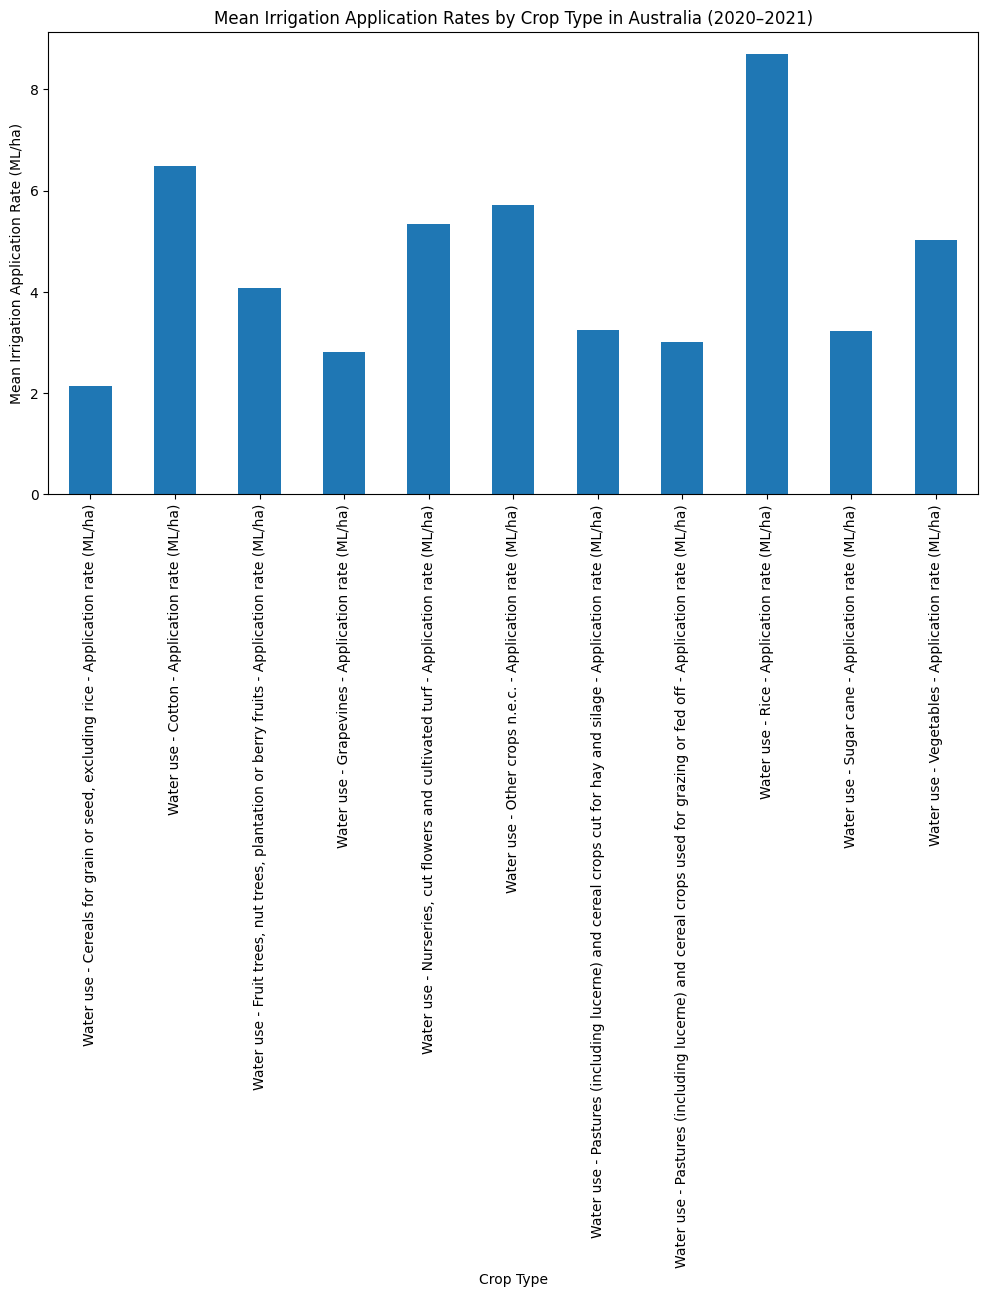

In [8]:
application_df["Crop"] = (
    application_df["Commodity description"]
    .str.extract(r'Water use - (.*?) - Application rate')
)

print(application_df["Crop"].head())

crop_mean = application_df.groupby("Crop")["Estimate"].mean()


crop_mean = application_df.groupby(
    "Commodity description"
)["Estimate"].mean()

print(crop_mean)



import matplotlib.pyplot as plt

crop_mean.plot(kind="bar", figsize=(12,6))

plt.ylabel("Mean Irrigation Application Rate (ML/ha)")
plt.xlabel("Crop Type")

plt.title(
    "Mean Irrigation Application Rates by Crop Type in Australia (2020–2021)"
)

plt.xticks(rotation=90)

plt.show()

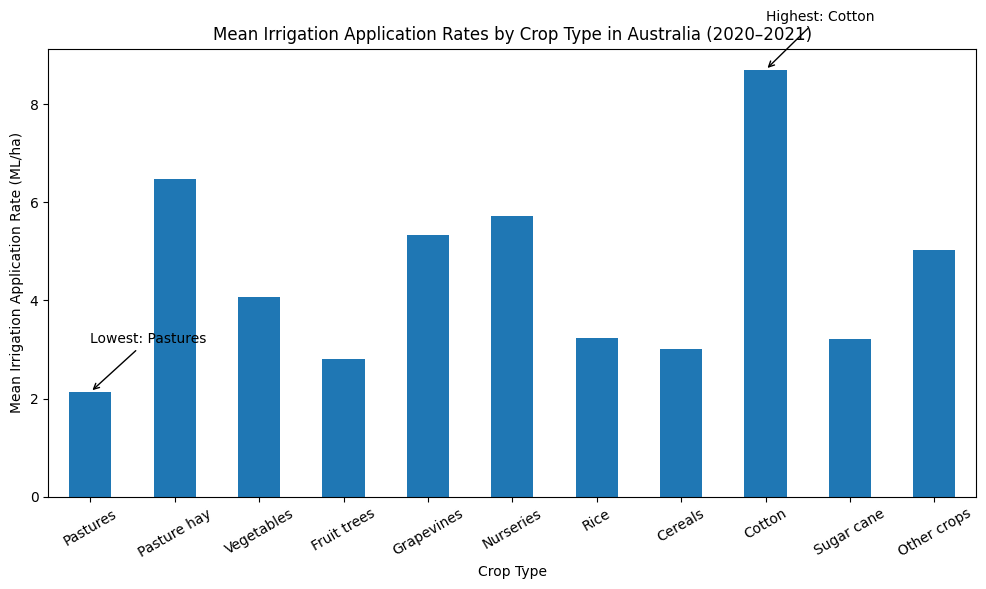

In [9]:
crop_mean.index = [
    "Pastures",
    "Pasture hay",
    "Vegetables",
    "Fruit trees",
    "Grapevines",
    "Nurseries",
    "Rice",
    "Cereals",
    "Cotton",
    "Sugar cane",
    "Other crops"
]

# Create bar chart
crop_mean.plot(
    kind="bar",
    figsize=(10,6)
)

# Labels and title
plt.ylabel("Mean Irrigation Application Rate (ML/ha)")
plt.xlabel("Crop Type")

plt.title(
    "Mean Irrigation Application Rates by Crop Type in Australia (2020–2021)"
)

# Rotate x labels
plt.xticks(rotation=30)

# Find highest and lowest crop
max_crop = crop_mean.idxmax()
min_crop = crop_mean.idxmin()

max_value = crop_mean.max()
min_value = crop_mean.min()

# Annotate highest value
plt.annotate(
    "Highest: Cotton",
    xy=(list(crop_mean.index).index(max_crop), max_value),
    xytext=(list(crop_mean.index).index(max_crop), max_value + 1),
    arrowprops=dict(arrowstyle="->")
)

# Annotate lowest value
plt.annotate(
    "Lowest: Pastures",
    xy=(list(crop_mean.index).index(min_crop), min_value),
    xytext=(list(crop_mean.index).index(min_crop), min_value + 1),
    arrowprops=dict(arrowstyle="->")
)





# Prevent labels being cut off
plt.tight_layout()

# Show graph
plt.show()